In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
DATASET_PATH_1 = "/content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB"
DATASET_PATH_2="/content/drive/MyDrive/Google AI Studio/cat_img"

In [3]:
print("Audio Folder:", DATASET_PATH_1)
print("Image Folder:", DATASET_PATH_2)

Audio Folder: /content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB
Image Folder: /content/drive/MyDrive/Google AI Studio/cat_img


In [4]:
!pip install librosa opencv-python scikit-learn matplotlib seaborn

In [5]:
import os
import cv2
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


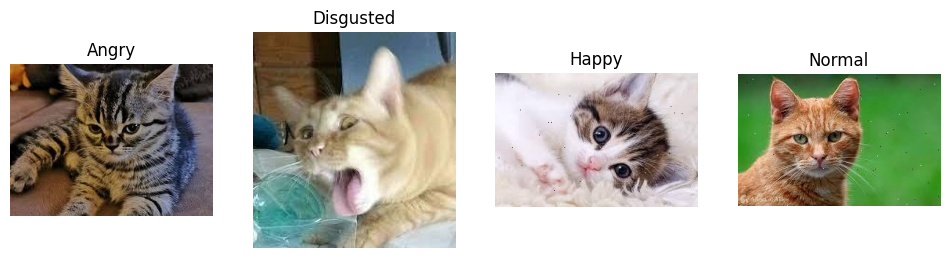

In [6]:
import os
import matplotlib.pyplot as plt

classes = sorted(os.listdir(DATASET_PATH_2))
plt.figure(figsize=(12,4))

plot_index = 1

for cls in classes:
    class_path = os.path.join(DATASET_PATH_2, cls)

    # skip if not a folder
    if not os.path.isdir(class_path):
        continue

    # get only image files
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # skip empty folders
    if len(images) == 0:
        print(f" No images in class: {cls}")
        continue

    img_path = os.path.join(class_path, images[0])
    img = plt.imread(img_path)

    plt.subplot(1, 4, plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

    plot_index += 1
    if plot_index > 4:
        break

plt.show()


In [7]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = 224
X_img, y_img = [], []

labels = ["Happy", "Sad", "Angry", "Scared"]

for idx, emotion in enumerate(labels):
    folder = os.path.join(DATASET_PATH_2, emotion)

    #  safety check
    if not os.path.exists(folder):
        print(f" Folder not found: {folder}")
        continue

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        # allow only image files
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img = cv2.imread(img_path)

        #  safety check
        if img is None:
            print(f" Skipping corrupted image: {img_path}")
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X_img.append(img)
        y_img.append(idx)

# convert to numpy
X_img = np.array(X_img, dtype=np.float32)
y_img = np.array(y_img)

#  check before split
print("Total images:", X_img.shape[0])
print("Labels count:", np.bincount(y_img))

# train-test split
X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    X_img,
    y_img,
    test_size=0.2,
    stratify=y_img,
    random_state=42
)

print("Train:", X_img_train.shape)
print("Test :", X_img_test.shape)


Total images: 1111
Labels count: [236 258 360 257]
Train: (888, 224, 224, 3)
Test : (223, 224, 224, 3)


In [8]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


In [9]:
cnn_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(4, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
cnn_callbacks = [
    ModelCheckpoint("best_cnn_model.keras", save_best_only=True, monitor="val_accuracy"),
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

cnn_history = cnn_model.fit(
    X_img_train, y_img_train,
    validation_data=(X_img_test, y_img_test),
    epochs=30,
    batch_size=32,
    callbacks=cnn_callbacks
)


Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.2624 - loss: 1.6008 - val_accuracy: 0.4350 - val_loss: 1.2808 - learning_rate: 1.0000e-04
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.4145 - loss: 1.3226 - val_accuracy: 0.5336 - val_loss: 1.1496 - learning_rate: 1.0000e-04
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.5214 - loss: 1.1139 - val_accuracy: 0.5695 - val_loss: 1.0600 - learning_rate: 1.0000e-04
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5935 - loss: 0.9755 - val_accuracy: 0.5874 - val_loss: 0.9869 - learning_rate: 1.0000e-04
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6716 - loss: 0.9228 - val_accuracy: 0.6054 - val_loss: 0.9174 - learning_rate: 1.0000e-04
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6839 - loss: 0.8494 - val_accuracy: 0.6682 - val_loss: 0.8657 - learning_rate: 1.0000e-04
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7173 - loss:

In [11]:
print(y_img_test.shape)


(223,)


In [12]:
import numpy as np

if len(y_img_test.shape) > 1:
    y_img_test_int = np.argmax(y_img_test, axis=1)
else:
    y_img_test_int = y_img_test


In [13]:
import numpy as np

# Predict class probabilities
y_pred_cnn = cnn_model.predict(X_img_test)

# Convert probabilities → class indices
y_pred_cnn = np.argmax(y_pred_cnn, axis=1)


7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


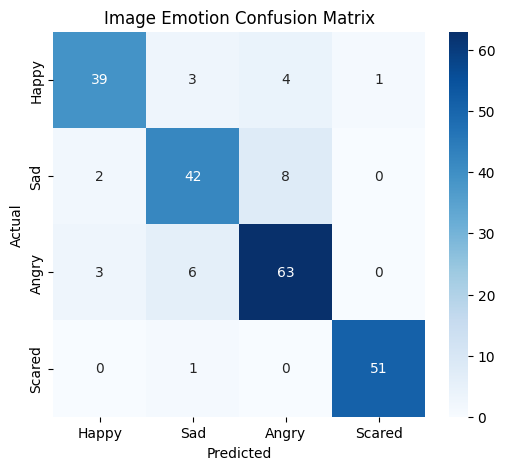

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_img = confusion_matrix(y_img_test, y_pred_cnn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_img, annot=True, fmt="d",
            xticklabels=labels, yticklabels=labels,
            cmap="Blues")
plt.title("Image Emotion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


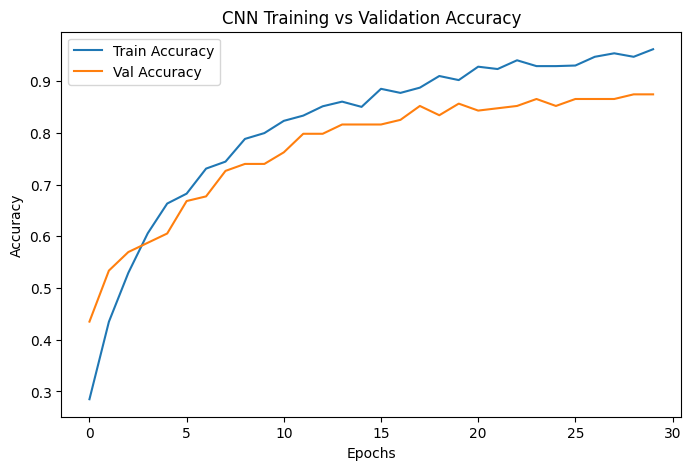

In [15]:
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()


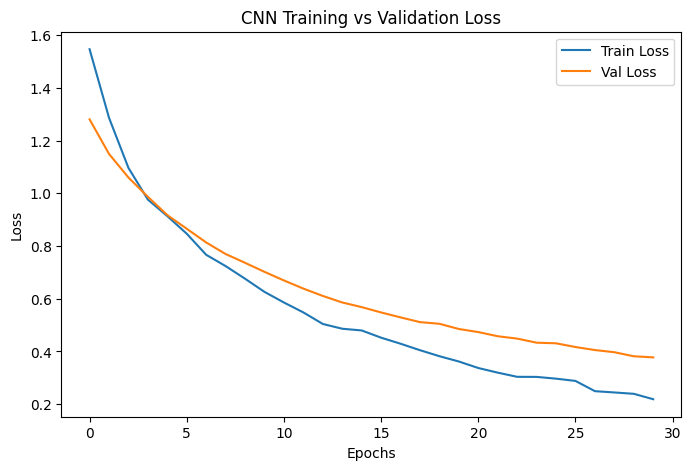

In [16]:
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()


In [17]:
def extract_mfcc(file_path, max_len=100):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc = mfcc.T

    if len(mfcc) < max_len:
        pad = max_len - len(mfcc)
        mfcc = np.pad(mfcc, ((0,pad),(0,0)))
    else:
        mfcc = mfcc[:max_len]

    return mfcc


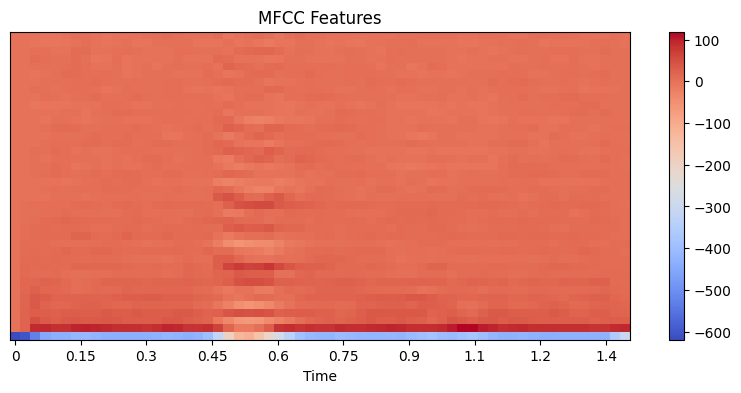

In [18]:
import librosa.display

sample_audio = None
for cls in labels:
    cls_path = os.path.join(DATASET_PATH_1, cls)
    sample_audio = os.path.join(cls_path, os.listdir(cls_path)[0])
    break

y, sr = librosa.load(sample_audio, sr=16000)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis="time")
plt.colorbar()
plt.title("MFCC Features")
plt.show()


In [19]:
import librosa
import numpy as np

def extract_mfcc(path, max_len=100):
    y, sr = librosa.load(path, sr=16000)

    if len(y) < sr * 0.2:   # too short audio
        return None

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc = mfcc.T

    if mfcc.shape[0] < max_len:
        pad = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0, pad), (0, 0)))
    else:
        mfcc = mfcc[:max_len, :]

    return mfcc


In [20]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

X_audio, y_audio = [], []

for idx, emotion in enumerate(labels):
    folder = os.path.join(DATASET_PATH_1, emotion)

    #  check folder exists
    if not os.path.exists(folder):
        print(f" Folder not found: {folder}")
        continue

    for file in os.listdir(folder):

        #  allow only mp3 files
        if not file.lower().endswith(".mp3"):
            continue

        path = os.path.join(folder, file)

        try:
            mfcc = extract_mfcc(path)
        except Exception as e:
            print(f" Error reading {path}: {e}")
            continue

        #  skip failed MFCC
        if mfcc is None:
            print(f" MFCC None: {path}")
            continue

        #  enforce fixed shape for LSTM
        if mfcc.shape != (100, 40):
            print(f" Wrong MFCC shape {mfcc.shape}: {path}")
            continue

        X_audio.append(mfcc)
        y_audio.append(idx)

# convert to numpy safely
X_audio = np.array(X_audio, dtype=np.float32)
y_audio = np.array(y_audio, dtype=np.int64)

print("Total audio samples:", len(X_audio))

#  stop early if dataset is empty
if len(X_audio) == 0:
    raise ValueError("No audio files loaded. Check dataset path and labels.")

print("Label counts:", np.bincount(y_audio))

# train-test split
X_audio_train, X_audio_test, y_audio_train, y_audio_test = train_test_split(
    X_audio,
    y_audio,
    test_size=0.2,
    stratify=y_audio,
    random_state=42
)

print("Train audio shape:", X_audio_train.shape)
print("Test audio shape :", X_audio_test.shape)


 Folder not found: /content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB/Sad
 Folder not found: /content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB/Scared
Total audio samples: 30
Label counts: [15  0 15]
Train audio shape: (24, 100, 40)
Test audio shape : (6, 100, 40)


In [21]:
def extract_audio_features(file_path, max_len=120):
    y, sr = librosa.load(file_path, sr=16000)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    # Delta & Delta-Delta
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    # Stack features
    features = np.vstack([mfcc, delta, delta2])  # (120, time)
    features = features.T

    # Padding / Truncation
    if len(features) < max_len:
        pad = max_len - len(features)
        features = np.pad(features, ((0, pad), (0, 0)))
    else:
        features = features[:max_len]

    return features


In [22]:
def augment_audio(y, sr):
    if np.random.rand() < 0.5:
        y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
    if np.random.rand() < 0.5:
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.randint(-2, 3))
    return y


In [23]:
def extract_audio_features_aug(file_path, max_len=120):
    y, sr = librosa.load(file_path, sr=16000)
    y = augment_audio(y, sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    features = np.vstack([mfcc, delta, delta2]).T

    if len(features) < max_len:
        features = np.pad(features, ((0, max_len - len(features)), (0, 0)))
    else:
        features = features[:max_len]

    return features



In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# flatten
X_audio_train_flat = X_audio_train.reshape(-1, X_audio_train.shape[-1])
X_audio_test_flat  = X_audio_test.reshape(-1, X_audio_test.shape[-1])

# scale
X_audio_train_scaled = scaler.fit_transform(X_audio_train_flat)
X_audio_test_scaled  = scaler.transform(X_audio_test_flat)

# reshape back
X_audio_train = X_audio_train_scaled.reshape(-1, 100, 40)
X_audio_test  = X_audio_test_scaled.reshape(-1, 100, 40)

print(X_audio_train.shape)
print(X_audio_test.shape)


(24, 100, 40)
(6, 100, 40)


In [25]:
from tensorflow.keras.layers import Bidirectional

audio_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(120,120)),
    Dropout(0.4),

    Bidirectional(LSTM(64)),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(4, activation="softmax")
])

audio_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

audio_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 120, 256)       │       254,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436,356 (1.66 MB)

 Trainable params: 436,356 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
import collections

y_audio_train_int = y_audio_train
y_audio_test_int  = y_audio_test

print("Train:", collections.Counter(y_audio_train_int))
print("Test :", collections.Counter(y_audio_test_int))


Train: Counter({np.int64(0): 12, np.int64(2): 12})
Test : Counter({np.int64(2): 3, np.int64(0): 3})


In [27]:
print(y_audio_train.shape)


(24,)


In [28]:
import numpy as np
import collections

if len(y_audio_train.shape) > 1:
    y_audio_train_int = np.argmax(y_audio_train, axis=1)
    y_audio_test_int  = np.argmax(y_audio_test, axis=1)
else:
    y_audio_train_int = y_audio_train
    y_audio_test_int  = y_audio_test

print("Train:", collections.Counter(y_audio_train_int))
print("Test :", collections.Counter(y_audio_test_int))


Train: Counter({np.int64(0): 12, np.int64(2): 12})
Test : Counter({np.int64(2): 3, np.int64(0): 3})


In [29]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_audio_train_int),
    y=y_audio_train_int
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

audio_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        verbose=1
    ),
    ModelCheckpoint(
        "best_audio_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [33]:
from tensorflow.keras.utils import to_categorical

y_audio_train = to_categorical(y_audio_train, num_classes=4)
y_audio_test  = to_categorical(y_audio_test, num_classes=4)

audio_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

audio_model = Sequential([
    LSTM(128, input_shape=(100, 40)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(4, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
callbacks = [
    ModelCheckpoint("best_audio_model.keras", monitor="val_accuracy", save_best_only=True),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
]


In [36]:
import numpy as np
import collections

def force_int_labels(y):
    y = np.array(y)

    # one-hot case
    if y.ndim > 1 and y.shape[-1] > 1:
        y = np.argmax(y, axis=1)

    # flatten + force Python int
    y = [int(np.array(v).flatten()[0]) for v in y]
    return y

y_audio_train_int = force_int_labels(y_audio_train)
y_audio_test_int  = force_int_labels(y_audio_test)

print("Train:", collections.Counter(y_audio_train_int))
print("Test :", collections.Counter(y_audio_test_int))


Train: Counter({0: 12, 2: 12})
Test : Counter({2: 3, 0: 3})


In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

audio_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        verbose=1
    ),
    ModelCheckpoint(
        "best_audio_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [38]:
# compile
audio_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# fit
history = audio_model.fit(
    X_audio_train,
    y_audio_train,                     # one-hot labels
    validation_data=(X_audio_test, y_audio_test),
    epochs=40,
    batch_size=16,
    callbacks=audio_callbacks
)


Epoch 1/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3542 - loss: 1.3841
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to best_audio_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 609ms/step - accuracy: 0.3472 - loss: 1.3860 - val_accuracy: 0.6667 - val_loss: 1.2023 - learning_rate: 0.0010
Epoch 2/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5833 - loss: 1.1721
Epoch 2: val_accuracy did not improve from 0.66667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5694 - loss: 1.1744 - val_accuracy: 0.6667 - val_loss: 1.0360 - learning_rate: 0.0010
Epoch 3/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7188 - loss: 0.9614
Epoch 3: val_accuracy did not improve from 0.66667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7292 - loss: 0.9574 - val_accuracy: 0.6667 - val_loss: 0.9092 - learning_rate: 0.0010
Epoch 4/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9583 - loss: 0.7407
Epoch 4: val_accuracy did not improve from 0.66667
2/2 ━━

In [39]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Convert to numpy
y_audio_train = np.asarray(y_audio_train)
y_audio_test  = np.asarray(y_audio_test)

print("Before fix:", y_audio_train.shape)

# Case 1: labels are (N,4,4) → FIX
if y_audio_train.ndim == 3:
    y_audio_train = np.argmax(y_audio_train, axis=-1)
    y_audio_test  = np.argmax(y_audio_test, axis=-1)

# Case 2: labels are integers → one-hot encode
if y_audio_train.ndim == 1:
    y_audio_train = to_categorical(y_audio_train, num_classes=4)
    y_audio_test  = to_categorical(y_audio_test, num_classes=4)

print("After fix:", y_audio_train.shape)


Before fix: (24, 4)
After fix: (24, 4)


In [40]:
audio_model = Sequential([
    LSTM(128, return_sequences=False, input_shape=(100,40)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dense(4, activation="softmax")
])

audio_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

audio_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 128)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,044 (371.27 KB)

 Trainable params: 95,044 (371.27 KB)

 Non-trainable params: 0 (0.00 B)

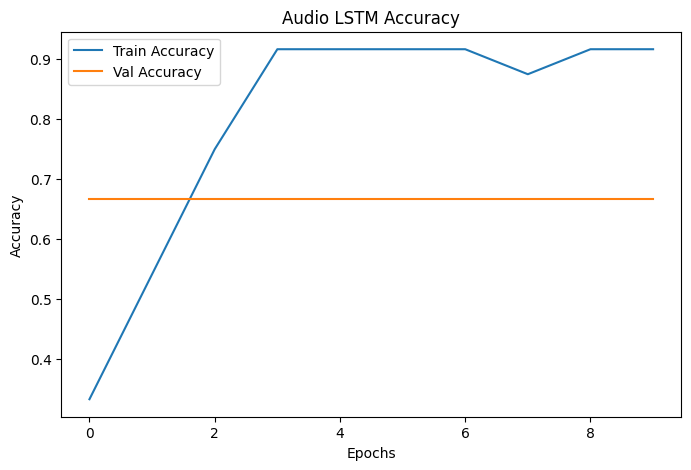

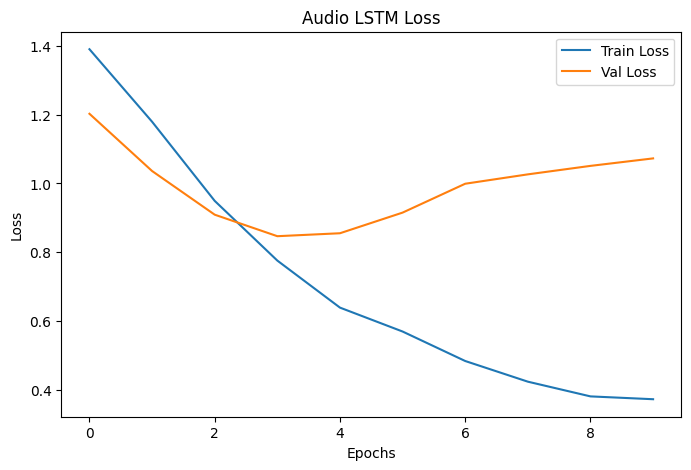

In [44]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Audio LSTM Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Audio LSTM Loss")
plt.legend()
plt.show()


In [45]:
y_pred_cnn = np.argmax(cnn_model.predict(X_img_test), axis=1)
print(classification_report(y_img_test, y_pred_cnn, target_names=labels))


7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
              precision    recall  f1-score   support

       Happy       0.89      0.83      0.86        47
         Sad       0.81      0.81      0.81        52
       Angry       0.84      0.88      0.86        72
      Scared       0.98      0.98      0.98        52

    accuracy                           0.87       223
   macro avg       0.88      0.87      0.88       223
weighted avg       0.88      0.87      0.87       223



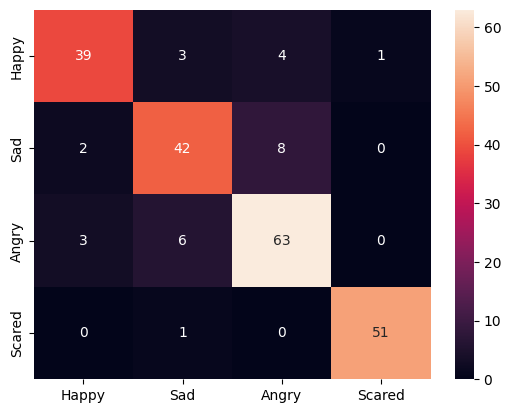

In [46]:
cm = confusion_matrix(y_img_test, y_pred_cnn)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.show()


In [49]:
import numpy as np

# convert one-hot to integer labels
y_audio_test_int = np.argmax(y_audio_test, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


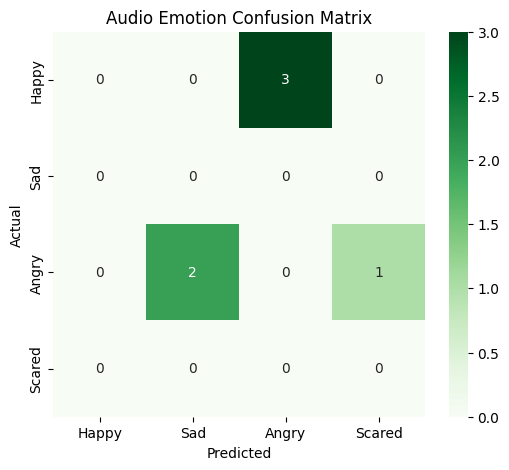

In [53]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_audio = np.argmax(audio_model.predict(X_audio_test), axis=1)

# Convert y_audio_test to integer labels SAFELY
if len(y_audio_test.shape) > 1:
    y_audio_test_int = np.argmax(y_audio_test, axis=1)
else:
    y_audio_test_int = y_audio_test

# Confusion Matrix
cm_audio = confusion_matrix(y_audio_test_int, y_pred_audio)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_audio,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Audio Emotion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


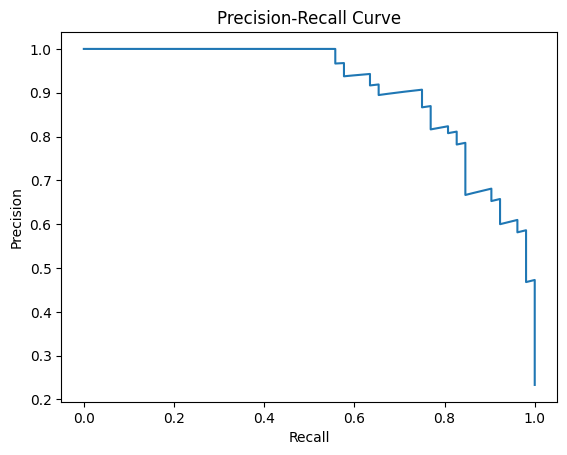

In [55]:
probs = cnn_model.predict(X_img_test)
precision, recall, _ = precision_recall_curve(y_img_test, probs[:,1], pos_label=1)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


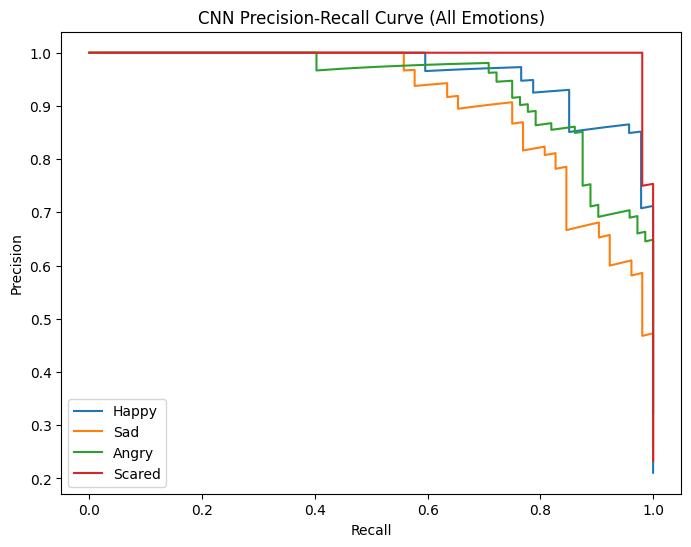

In [56]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve

y_test_bin = label_binarize(y_img_test, classes=[0,1,2,3])
probs = cnn_model.predict(X_img_test)

plt.figure(figsize=(8,6))
for i, cls in enumerate(labels):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
    plt.plot(recall, precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CNN Precision-Recall Curve (All Emotions)")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


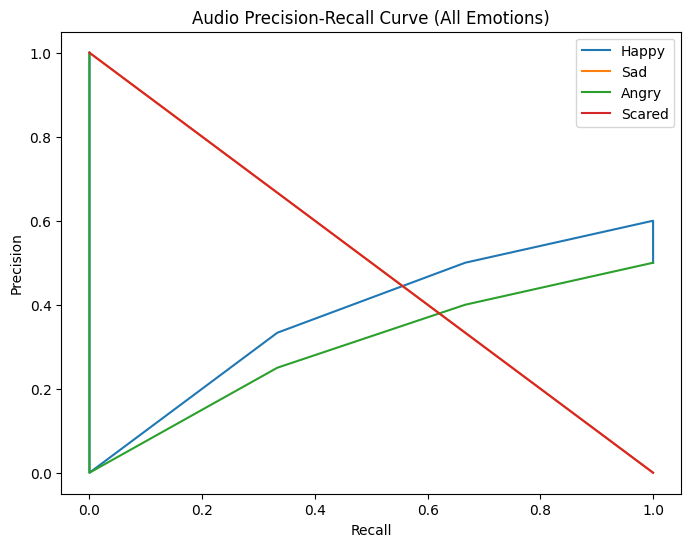

In [57]:
y_audio_bin = label_binarize(y_audio_test, classes=[0,1,2,3])
probs_audio = audio_model.predict(X_audio_test)

plt.figure(figsize=(8,6))
for i, cls in enumerate(labels):
    precision, recall, _ = precision_recall_curve(y_audio_bin[:,i], probs_audio[:,i])
    plt.plot(recall, precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Audio Precision-Recall Curve (All Emotions)")
plt.legend()
plt.show()
